# Predição de Casos SRAG — Montes Claros / MG

**Modelo:** SARIMAX com variáveis meteorológicas do INMET  
**Target:** casos SRAG não-COVID por semana  
**Município:** Montes Claros — MG (IBGE: 314330) | Estação INMET: A507  
**Período:** 2019–2025 (modelo: 2023 em diante — janela pós-pandemia limpa)

---
**Seções:**
1. Configuração e importações
2. Carregamento dos dados (SIVEP-SRAG + INMET)
3. Pré-processamento e agregação semanal
4. Evidências meteorológicas
5. Preparação do modelo (Estratégia A+C)
6. Treinamento SARIMAX — walk-forward CV
7. Resultados e métricas

## 1. Configuração e Importações

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr
from itertools import product
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110

# ── Caminhos ─────────────────────────────────────────────────────────────
# Ajuste DATA_DIR conforme necessário.
# Padrão: os dados ficam em ../bb/data/ relativos a este notebook.
_here = Path().resolve()
DATA_DIR = _here.parent / 'bb' / 'data'
OUTPUTS_DIR = _here / 'outputs'
OUTPUTS_DIR.mkdir(exist_ok=True)

print(f"DATA_DIR  : {DATA_DIR}")
print(f"OUTPUTS   : {OUTPUTS_DIR}")

# ── Constantes ───────────────────────────────────────────────────────────
CO_MOC = 314330.0  # IBGE Montes Claros

SRAG_COLS = [
    'NU_NOTIFIC', 'DT_NOTIFIC', 'SEM_NOT', 'DT_SIN_PRI', 'SEM_PRI',
    'ID_MUNICIP', 'CO_MUN_NOT', 'CS_SEXO', 'NU_IDADE_N',
    'HOSPITAL', 'UTI', 'EVOLUCAO', 'CLASSI_FIN',
]

CLIM_SHOW  = ['temp_min', 'umid_min', 'amp_term', 'orvalho_med', 'precip']
CLIM_LABEL = {
    'temp_min':    'Temp. Mínima (°C)',
    'umid_min':    'Umid. Mín. (%)',
    'amp_term':    'Amplitude Térmica (°C)',
    'orvalho_med': 'Pto. Orvalho (°C)',
    'precip':      'Precipitação (mm)',
}

print("\n✓ Configuração concluída.")

DATA_DIR  : /home/gabriel/dev/hackaton/bb/data
OUTPUTS   : /home/gabriel/dev/hackaton/srag_predicao/outputs

✓ Configuração concluída.


## 2. Carregamento dos Dados

### 2a. SIVEP-SRAG — Montes Claros (2019–2025)

In [3]:
frames = []
for ano in range(19, 26):
    path = DATA_DIR / 'srag_moc' / f'srag_moc_{ano:02d}.csv'
    cols_available = pd.read_csv(path, encoding='latin1', nrows=0).columns.tolist()
    use_cols = [c for c in SRAG_COLS if c in cols_available]
    df_tmp = pd.read_csv(path, encoding='latin1', sep=',', usecols=use_cols, low_memory=False)
    df_tmp['_fonte_ano'] = 2000 + ano
    frames.append(df_tmp)

srag_raw = pd.concat(frames, ignore_index=True)

for col in ['DT_NOTIFIC', 'DT_SIN_PRI']:
    if col in srag_raw.columns:
        srag_raw[col] = pd.to_datetime(srag_raw[col], errors='coerce')

srag_raw['CLASSI_FIN'] = pd.to_numeric(srag_raw['CLASSI_FIN'], errors='coerce')

# Filtrar Montes Claros
srag = srag_raw[srag_raw['CO_MUN_NOT'] == CO_MOC].copy().reset_index(drop=True)

print(f"SRAG bruto total  : {len(srag_raw):>7} registros")
print(f"SRAG Montes Claros: {len(srag):>7} registros")
print(f"Período           : {srag['DT_NOTIFIC'].min().date()} → {srag['DT_NOTIFIC'].max().date()}")
print(f"\nDistribuição por CLASSI_FIN:")
print(srag['CLASSI_FIN'].value_counts(dropna=False).rename({1:'Influenza',2:'Outro vírus',
      3:'Outro agente',4:'Não especif.',5:'COVID-19'}).to_string())

SRAG bruto total  :   13294 registros
SRAG Montes Claros:   13294 registros
Período           : 2019-02-06 → 2026-01-07

Distribuição por CLASSI_FIN:
CLASSI_FIN
Não especif.    6987
COVID-19        5134
Outro vírus      815
Influenza        204
NaN              152
Outro agente       2


### 2b. INMET — Estação A507 (dados horários, 2019–2025)

In [4]:
def load_inmet_year(path):
    df = pd.read_csv(
        path, sep=';', decimal=',',
        encoding='utf-8-sig', quotechar='"', low_memory=False,
    )
    df.columns = [c.strip().lstrip('\ufeff').strip('"') for c in df.columns]
    for col in df.columns:
        if col not in ['Data', 'Hora (UTC)']:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    df['Data'] = pd.to_datetime(df['Data'], format='%d/%m/%Y', errors='coerce')
    return df.dropna(subset=['Data']).sort_values('Data').reset_index(drop=True)

rename_map = {
    'Temp. Max. (C)': 'temp_max', 'Temp. Min. (C)': 'temp_min',
    'Temp. Ins. (C)': 'temp_inst',
    'Umi. Min. (%)':  'umid_min',  'Umi. Ins. (%)': 'umid_inst',
    'Pto Orvalho Ins. (C)': 'orvalho_inst',
    'Chuva (mm)': 'chuva', 'Data': 'data',
}

inmet_frames = []
for ano in range(19, 26):
    path = DATA_DIR / 'inmet' / f'inmet_{ano:02d}.csv'
    try:
        df_tmp = load_inmet_year(path)
        inmet_frames.append(df_tmp)
        print(f"inmet_{ano:02d}: {df_tmp.shape[0]:>6} linhas  "
              f"{df_tmp['Data'].min().date()} → {df_tmp['Data'].max().date()}")
    except FileNotFoundError:
        print(f"inmet_{ano:02d}: não encontrado")

inmet_raw = pd.concat(inmet_frames, ignore_index=True)
inmet_raw = inmet_raw.rename(columns={k: v for k, v in rename_map.items() if k in inmet_raw.columns})
if 'Data' in inmet_raw.columns and 'data' not in inmet_raw.columns:
    inmet_raw = inmet_raw.rename(columns={'Data': 'data'})

# Limpar valores impossíveis
limits = {
    'temp_inst': (-20, 60), 'temp_max': (-20, 60), 'temp_min': (-20, 60),
    'umid_inst': (0, 100),  'umid_min': (0, 100),
    'chuva': (0, 300),
}
for col, (lo, hi) in limits.items():
    if col in inmet_raw.columns:
        inmet_raw.loc[(inmet_raw[col] < lo) | (inmet_raw[col] > hi), col] = np.nan

print(f"\nINMET consolidado — {inmet_raw.shape[0]} registros horários")
print(f"Colunas: {[c for c in inmet_raw.columns if c != 'Hora (UTC)'][:12]}")

inmet_19:   8760 linhas  2019-01-01 → 2019-12-31
inmet_20:   8784 linhas  2020-01-01 → 2020-12-31
inmet_21:   8760 linhas  2021-01-01 → 2021-12-31
inmet_22:   8760 linhas  2022-01-01 → 2022-12-31
inmet_23:   8760 linhas  2023-01-01 → 2023-12-31
inmet_24:   8784 linhas  2024-01-01 → 2024-12-31
inmet_25:   8760 linhas  2025-01-01 → 2025-12-31

INMET consolidado — 61368 registros horários
Colunas: ['data', 'temp_inst', 'temp_max', 'temp_min', 'umid_inst', 'Umi. Max. (%)', 'umid_min', 'orvalho_inst', 'Pto Orvalho Max. (C)', 'Pto Orvalho Min. (C)', 'Pressao Ins. (hPa)', 'Pressao Max. (hPa)']


## 3. Pré-processamento e Agregação Semanal

In [5]:
# ── Agregação diária INMET ────────────────────────────────────────────────
inmet_daily = (
    inmet_raw
    .groupby('data')
    .agg(
        temp_min_d   =('temp_min',    'min'),
        temp_max_d   =('temp_max',    'max'),
        umid_min_d   =('umid_min',    'min'),
        orvalho_med  =('orvalho_inst','mean'),
        chuva_tot    =('chuva',       'sum'),
    )
    .reset_index()
)
inmet_daily['amplitude_term'] = inmet_daily['temp_max_d'] - inmet_daily['temp_min_d']

# ── Agregação semanal INMET ───────────────────────────────────────────────
inmet_daily['semana'] = inmet_daily['data'].dt.to_period('W')
inmet_wk = (
    inmet_daily
    .groupby('semana')
    .agg(
        temp_min     =('temp_min_d',    'min'),
        umid_min     =('umid_min_d',    'min'),
        orvalho_med  =('orvalho_med',   'mean'),
        precip       =('chuva_tot',     'sum'),
        amp_term     =('amplitude_term','mean'),
    )
    .reset_index()
)

# ── Agregação semanal SRAG ────────────────────────────────────────────────
def add_semana(df):
    dt = df['DT_SIN_PRI'].fillna(df['DT_NOTIFIC'])
    return dt.dt.to_period('W')

srag['semana'] = add_semana(srag)

srag_wk_total = srag['semana'].dropna().value_counts().sort_index().rename('total')
covid_mask    = srag['CLASSI_FIN'] == 5
srag_wk_covid = srag.loc[covid_mask, 'semana'].dropna().value_counts().sort_index().rename('covid')
srag_wk_nao   = srag.loc[~covid_mask, 'semana'].dropna().value_counts().sort_index().rename('nao_covid')

srag_wk = (
    pd.concat([srag_wk_total, srag_wk_covid, srag_wk_nao], axis=1)
    .fillna(0).astype(int)
    .reset_index().rename(columns={'index': 'semana'})
)

# ── Merge INMET × SRAG ───────────────────────────────────────────────────
weekly = inmet_wk.merge(srag_wk, on='semana', how='inner')
weekly['pct_covid'] = weekly['covid'] / weekly['total'].replace(0, np.nan)
weekly['data_ref']  = weekly['semana'].dt.to_timestamp()
weekly['ano']       = weekly['semana'].dt.year.astype(int)
weekly['sem_num']   = weekly['semana'].dt.week.astype(int)
weekly = weekly.sort_values('data_ref').reset_index(drop=True)

print(f"Semanas INMET × SRAG: {len(weekly)}")
print(f"Período: {weekly['data_ref'].min().date()} → {weekly['data_ref'].max().date()}")
print(f"Média casos SRAG não-COVID/sem: {weekly['nao_covid'].mean():.1f}")
weekly[['semana','temp_min','umid_min','precip','nao_covid','covid','pct_covid']].head()

Semanas INMET × SRAG: 340
Período: 2019-01-28 → 2025-12-29
Média casos SRAG não-COVID/sem: 24.0


,semana,temp_min,umid_min,precip,nao_covid,covid,pct_covid
0,2019-01-28/2019-02-03,19.3,16.0,0.0,1,0,0.0
1,2019-02-25/2019-03-03,19.1,26.0,45.8,1,0,0.0
2,2019-03-18/2019-03-24,20.5,31.0,78.8,2,0,0.0
3,2019-03-25/2019-03-31,18.3,38.0,19.6,1,0,0.0
4,2019-04-01/2019-04-07,17.4,29.0,3.2,1,0,0.0


## 4. Evidências Meteorológicas

### 4a. Correlação de Spearman por variável × lag (0–8 semanas)

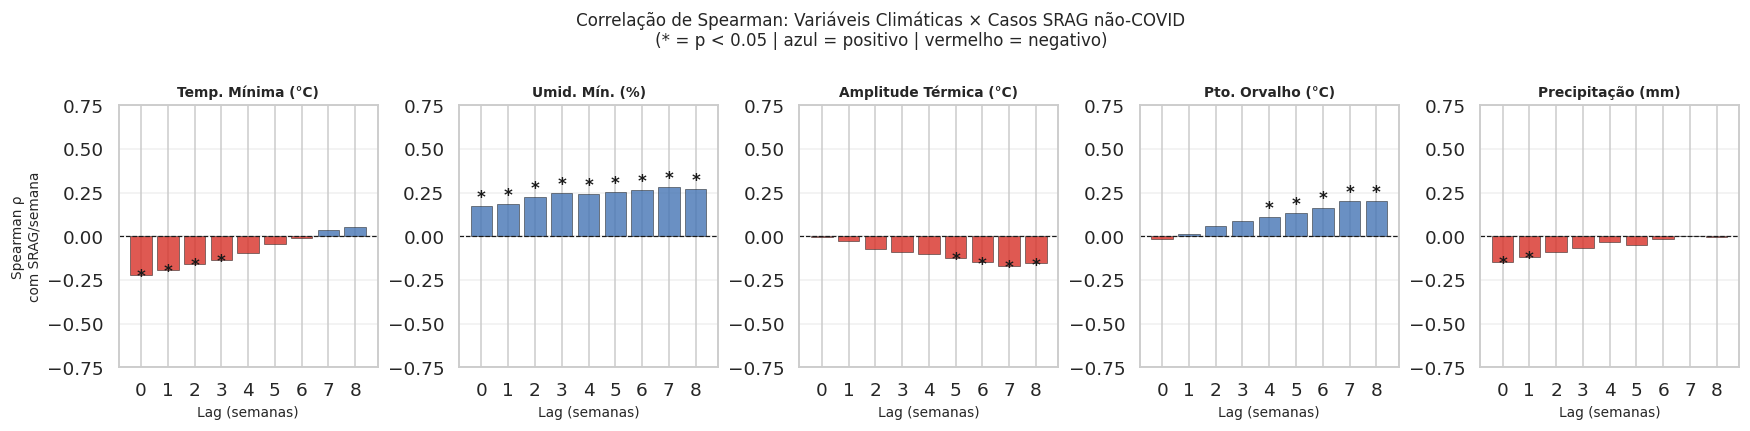

Figura salva: evidencia_1_correlacao_lag.png


In [6]:
# Engenharia de features de lag para a análise de evidências
w_ev = weekly.copy()
for var in CLIM_SHOW:
    for lag in range(1, 9):
        w_ev[f'{var}_lag{lag}'] = w_ev[var].shift(lag)

LAG_RANGE = range(0, 9)
target_ev = 'nao_covid'

fig, axes = plt.subplots(1, len(CLIM_SHOW), figsize=(16, 4), sharey=False)

for ax, var in zip(axes, CLIM_SHOW):
    rhos, pvals, lags_plot = [], [], []
    for lag in LAG_RANGE:
        col = f'{var}_lag{lag}' if lag > 0 else var
        if col not in w_ev.columns:
            continue
        valid = w_ev[[col, target_ev]].dropna()
        if len(valid) < 20:
            continue
        r, p = spearmanr(valid[col], valid[target_ev])
        rhos.append(r); pvals.append(p); lags_plot.append(lag)

    colors_bar = ['#d73027' if r < 0 else '#4575b4' for r in rhos]
    ax.bar(lags_plot, rhos, color=colors_bar, alpha=0.8, edgecolor='k', lw=0.4)

    for lag_v, r_v, p_v in zip(lags_plot, rhos, pvals):
        if p_v < 0.05:
            ax.text(lag_v, r_v + (0.02 if r_v >= 0 else -0.04), '*',
                    ha='center', fontsize=11, fontweight='bold', color='k')

    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xticks(list(LAG_RANGE))
    ax.set_xlabel('Lag (semanas)', fontsize=9)
    ax.set_title(CLIM_LABEL.get(var, var), fontsize=9, fontweight='bold')
    ax.set_ylim(-0.75, 0.75)
    if var == CLIM_SHOW[0]:
        ax.set_ylabel("Spearman ρ\ncom SRAG/semana", fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(
    'Correlação de Spearman: Variáveis Climáticas × Casos SRAG não-COVID\n'
    '(* = p < 0.05 | azul = positivo | vermelho = negativo)',
    fontsize=11
)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'evidencia_1_correlacao_lag.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva: evidencia_1_correlacao_lag.png")

### 4b. Sazonalidade — SRAG × Temperatura Mínima

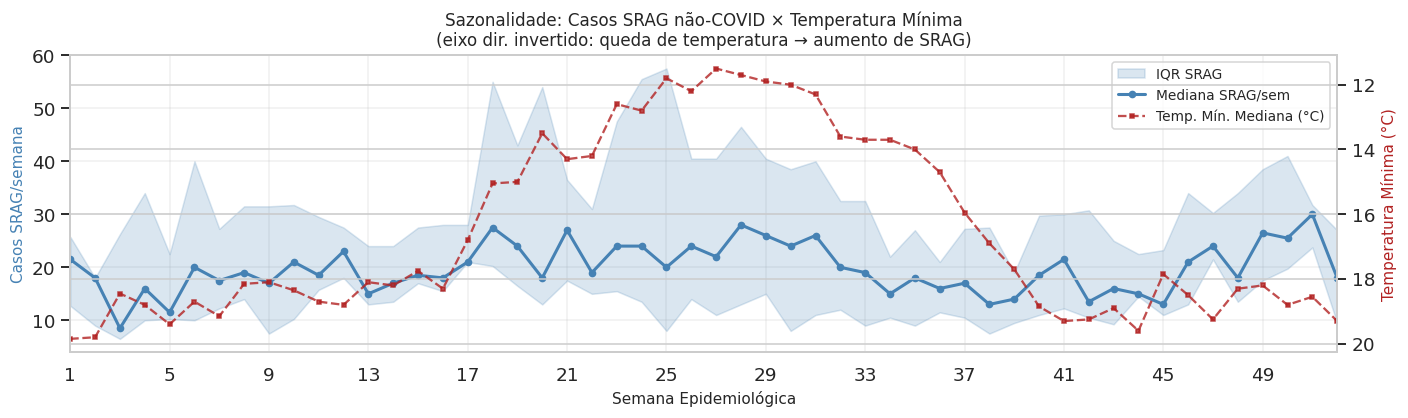

Figura salva: evidencia_2_sazonalidade.png


In [7]:
w_ev2 = w_ev.dropna(subset=[target_ev, 'temp_min', 'sem_num']).copy()
sem_grp = w_ev2.groupby('sem_num').agg(
    srag_med  =(target_ev, 'median'),
    srag_q25  =(target_ev, lambda x: np.percentile(x, 25)),
    srag_q75  =(target_ev, lambda x: np.percentile(x, 75)),
    temp_med  =('temp_min', 'median'),
).reset_index()

fig, ax_s = plt.subplots(figsize=(13, 4))
ax_t = ax_s.twinx()

ax_s.fill_between(sem_grp['sem_num'], sem_grp['srag_q25'], sem_grp['srag_q75'],
                  color='steelblue', alpha=0.20, label='IQR SRAG')
ax_s.plot(sem_grp['sem_num'], sem_grp['srag_med'],
          'o-', color='steelblue', lw=2, ms=4, label='Mediana SRAG/sem')
ax_t.plot(sem_grp['sem_num'], sem_grp['temp_med'],
          's--', color='firebrick', lw=1.5, ms=3, alpha=0.8, label='Temp. Mín. Mediana (°C)')

ax_s.set_xlabel('Semana Epidemiológica', fontsize=10)
ax_s.set_ylabel('Casos SRAG/semana', color='steelblue', fontsize=10)
ax_t.set_ylabel('Temperatura Mínima (°C)', color='firebrick', fontsize=10)
ax_t.invert_yaxis()  # eixo invertido: queda de temperatura → subida de SRAG
ax_s.set_xticks(range(1, 53, 4))
ax_s.set_xlim(1, 52)

lines1, labels1 = ax_s.get_legend_handles_labels()
lines2, labels2 = ax_t.get_legend_handles_labels()
ax_s.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)
ax_s.set_title(
    'Sazonalidade: Casos SRAG não-COVID × Temperatura Mínima\n'
    '(eixo dir. invertido: queda de temperatura → aumento de SRAG)',
    fontsize=11
)
ax_s.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'evidencia_2_sazonalidade.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva: evidencia_2_sazonalidade.png")

### 4c. Dispersão — lag ótimo × casos SRAG

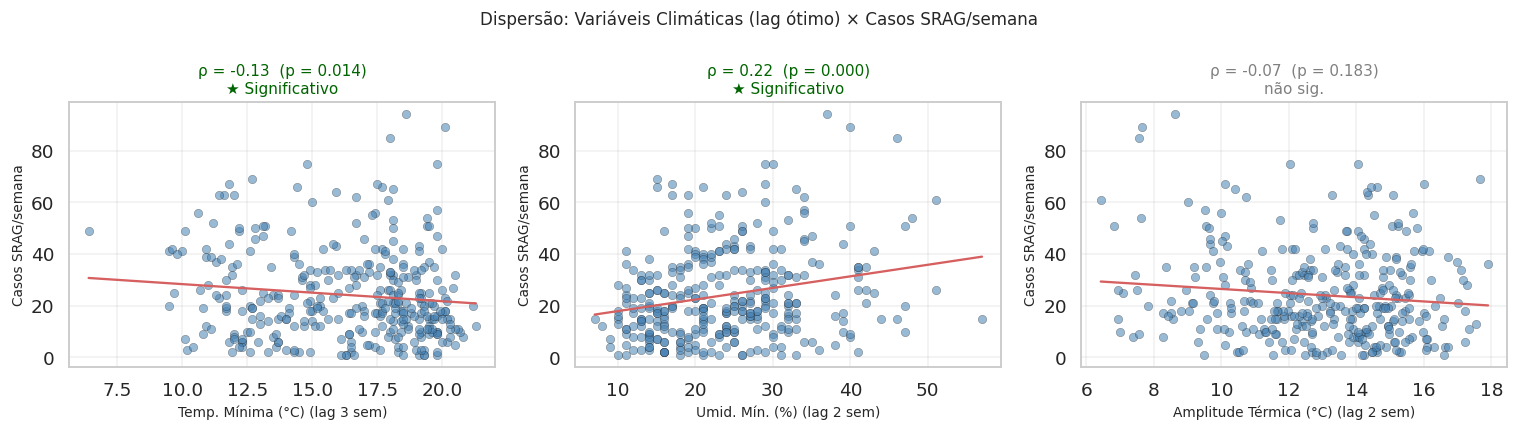


────────────────────────────────────────────────────────────
  Correlações Significativas por Variável (lag ótimo)
────────────────────────────────────────────────────────────
  Temp. Mínima (°C)            lag=0  ρ=-0.220  ✓
  Umid. Mín. (%)               lag=7  ρ=+0.283  ✓
  Amplitude Térmica (°C)       lag=7  ρ=-0.167  ✓
  Pto. Orvalho (°C)            lag=8  ρ=+0.204  ✓
  Precipitação (mm)            lag=0  ρ=-0.145  ✓
────────────────────────────────────────────────────────────


In [8]:
best_lags = {'temp_min': 3, 'umid_min': 2, 'amp_term': 2}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (var, lag) in zip(axes, best_lags.items()):
    col = f'{var}_lag{lag}'
    if col not in w_ev.columns:
        continue
    valid = w_ev[[col, target_ev]].dropna()
    rho, pval = spearmanr(valid[col], valid[target_ev])
    ax.scatter(valid[col], valid[target_ev], alpha=0.55, s=30,
               color='steelblue', edgecolors='k', lw=0.3)
    z = np.polyfit(valid[col], valid[target_ev], 1)
    xp = np.linspace(valid[col].min(), valid[col].max(), 100)
    ax.plot(xp, np.poly1d(z)(xp), 'r-', lw=1.5)
    ax.set_xlabel(f'{CLIM_LABEL.get(var,var)} (lag {lag} sem)', fontsize=9)
    ax.set_ylabel('Casos SRAG/semana', fontsize=9)
    ax.set_title(f'ρ = {rho:.2f}  (p = {pval:.3f})\n'
                 f'{"★ Significativo" if pval < 0.05 else "não sig."}',
                 fontsize=10,
                 color='darkgreen' if pval < 0.05 else 'gray')
    ax.grid(alpha=0.3)

fig.suptitle('Dispersão: Variáveis Climáticas (lag ótimo) × Casos SRAG/semana', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'evidencia_3_scatter_lag.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Resumo numérico ───────────────────────────────────────────────────────
print('\n' + '─'*60)
print('  Correlações Significativas por Variável (lag ótimo)')
print('─'*60)
for var in CLIM_SHOW:
    best_r, best_lag_v, best_p = 0, 0, 1.0
    for lag in LAG_RANGE:
        col = f'{var}_lag{lag}' if lag > 0 else var
        if col not in w_ev.columns:
            continue
        valid = w_ev[[col, target_ev]].dropna()
        if len(valid) < 20:
            continue
        r, p = spearmanr(valid[col], valid[target_ev])
        if abs(r) > abs(best_r):
            best_r, best_lag_v, best_p = r, lag, p
    sig = '✓' if best_p < 0.05 else '✗'
    print(f"  {CLIM_LABEL.get(var,var):<28} lag={best_lag_v}  "
          f"ρ={best_r:+.3f}  {sig}")
print('─'*60)

## 5. Preparação do Modelo — Estratégia A+C

- **Estratégia A**: excluir semanas com >60 % COVID (sinal epidêmico distorce correlação climática)
- **Estratégia C**: usar apenas dados a partir de 2023 (janela pós-pandemia limpa)
- **Features exógenas**: lags defasados das variáveis climáticas + termos circulares de sazonalidade

Semanas após filtro A+C : 158
Período                 : 2022-12-26 → 2025-12-29
Target (nao_covid)      : média=19.2  std=14.0  min=2  max=75
Variáveis exógenas (7): ['temp_min_lag3', 'umid_min_lag2', 'orvalho_med_lag2', 'amp_term_lag2', 'precip_lag3', 'sin_sem', 'cos_sem']


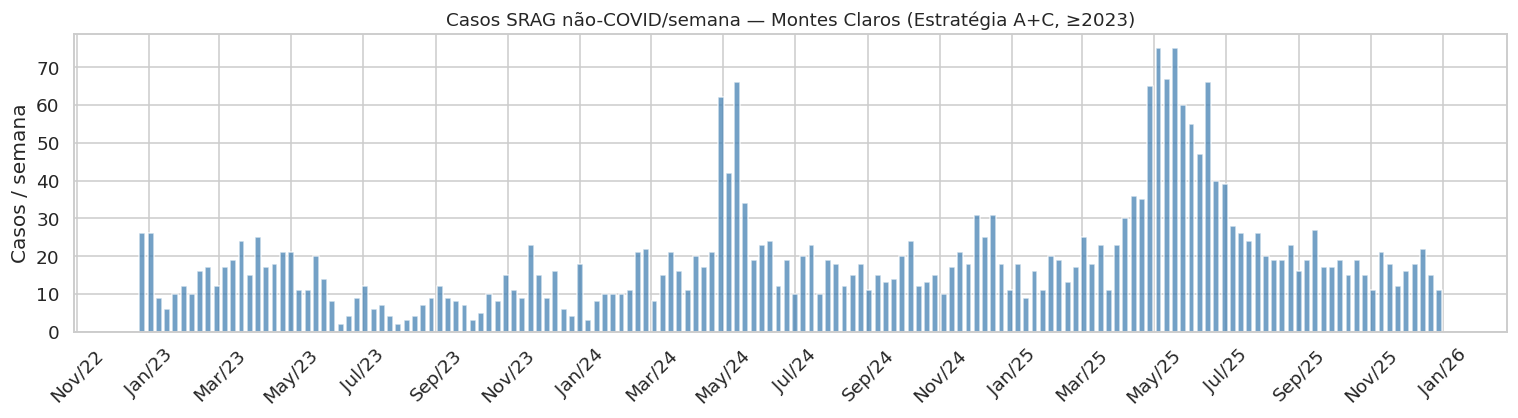

In [9]:
# ── Engenharia de features ────────────────────────────────────────────────
w18 = weekly.copy()
CLIM_BASE = [c for c in CLIM_SHOW if c in w18.columns]

for col in CLIM_BASE:
    for lag in range(1, 9):
        w18[f'{col}_lag{lag}'] = w18[col].shift(lag)

w18['sin_sem'] = np.sin(2 * np.pi * w18['sem_num'] / 52)
w18['cos_sem'] = np.cos(2 * np.pi * w18['sem_num'] / 52)
w18.dropna(inplace=True)

# ── Normalizar pct_covid → fração (0–1) ──────────────────────────────────
if w18['pct_covid'].max() > 1.5:
    w18['pct_covid'] = w18['pct_covid'] / 100.0

# ── Aplicar Estratégia A+C ────────────────────────────────────────────────
mask_AC = (w18['pct_covid'] < 0.60) & (w18['ano'] >= 2023)
df_model = w18[mask_AC].copy().reset_index(drop=True)

# ── Variáveis exógenas para SARIMAX ──────────────────────────────────────
EXOG_SARIMAX = [c for c in [
    'temp_min_lag3', 'umid_min_lag2', 'orvalho_med_lag2',
    'amp_term_lag2', 'precip_lag3', 'sin_sem', 'cos_sem'
] if c in df_model.columns]

y = df_model['nao_covid'].values.astype(float)
X = df_model[EXOG_SARIMAX].values.astype(float)
dates = pd.to_datetime(df_model['data_ref'])

print(f"Semanas após filtro A+C : {len(df_model)}")
print(f"Período                 : {dates.min().date()} → {dates.max().date()}")
print(f"Target (nao_covid)      : média={y.mean():.1f}  std={y.std():.1f}  "
      f"min={y.min():.0f}  max={y.max():.0f}")
print(f"Variáveis exógenas ({len(EXOG_SARIMAX)}): {EXOG_SARIMAX}")

# ── Visualization — série do target ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(dates, y, width=5, color='steelblue', alpha=0.75)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.set_title('Casos SRAG não-COVID/semana — Montes Claros (Estratégia A+C, ≥2023)', fontsize=12)
ax.set_ylabel('Casos / semana')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'target_srag_serie.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Treinamento SARIMAX — Walk-Forward Cross-Validation

### 6a. Seleção de ordem via grid search (AIC)

In [10]:
# ── Teste de estacionariedade (ADF) ───────────────────────────────────────
adf_stat, adf_pval = adfuller(y, autolag='AIC')[:2]
d = 0 if adf_pval < 0.05 else 1
print(f"ADF: estatística={adf_stat:.3f}  p-value={adf_pval:.4f}  →  d recomendado = {d}")

# ── Grid search (p,q) ────────────────────────────────────────────────────
print("\nGrid search SARIMAX (p, q) ∈ {0,1,2,3}² …")
grid_results = []
for p, q in product(range(4), range(4)):
    try:
        m = SARIMAX(
            y, exog=X, order=(p, d, q),
            seasonal_order=(0, 0, 0, 0),
            enforce_stationarity=False,
            enforce_invertibility=False,
            trend='n',
        ).fit(disp=False, maxiter=200)
        grid_results.append({'p': p, 'd': d, 'q': q, 'AIC': m.aic, 'BIC': m.bic})
    except Exception:
        pass

grid_df  = pd.DataFrame(grid_results).sort_values('AIC')
best_row = grid_df.iloc[0]
order    = (int(best_row.p), int(best_row.d), int(best_row.q))

print(f"\nTop 5 resultados (por AIC):")
print(grid_df.head(5).to_string(index=False))
print(f"\n→ Melhor ordem selecionada: SARIMAX{order}  AIC={best_row.AIC:.1f}")

ADF: estatística=-2.973  p-value=0.0375  →  d recomendado = 0

Grid search SARIMAX (p, q) ∈ {0,1,2,3}² …

Top 5 resultados (por AIC):
 p  d  q         AIC         BIC
 1  0  3 1094.426316 1130.869748
 2  0  3 1095.990162 1135.470546
 3  0  3 1097.716715 1140.234052
 1  0  2 1099.488003 1132.965679
 2  0  2 1100.989368 1137.510470

→ Melhor ordem selecionada: SARIMAX(1, 0, 3)  AIC=1094.4


### 6b. Walk-forward — previsão 1-step-ahead

In [11]:
MIN_TRAIN = max(20, order[0] + order[2] + 5)
preds, actuals, pred_dates = [], [], []

print(f"Walk-forward: {len(y) - MIN_TRAIN} predições (treino mínimo={MIN_TRAIN} sem) …")
for t in range(MIN_TRAIN, len(y)):
    try:
        res = SARIMAX(
            y[:t], exog=X[:t],
            order=order,
            seasonal_order=(0, 0, 0, 0),
            enforce_stationarity=False,
            enforce_invertibility=False,
            trend='n',
        ).fit(disp=False, maxiter=200)
        pred = float(res.forecast(steps=1, exog=X[t:t+1])[0])
        pred = max(0.0, pred)
    except Exception:
        pred = float(y[t-1])
    preds.append(pred)
    actuals.append(y[t])
    pred_dates.append(dates.iloc[t])

preds   = np.array(preds)
actuals = np.array(actuals)

mae  = mean_absolute_error(actuals, preds)
mape = mean_absolute_percentage_error(actuals + 1, preds + 1) * 100
r2   = np.corrcoef(actuals, preds)[0, 1] ** 2

print(f"\n{'─'*50}")
print(f"  SARIMAX{order}  —  resultados walk-forward")
print(f"  MAE  : {mae:.2f} casos/semana")
print(f"  MAPE : {mape:.1f}%")
print(f"  R²   : {r2:.3f}")
print(f"  Série: média={actuals.mean():.1f}  std={actuals.std():.1f}")
print(f"{'─'*50}")

Walk-forward: 138 predições (treino mínimo=20 sem) …


/home/gabriel/dev/hackaton/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/gabriel/dev/hackaton/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/gabriel/dev/hackaton/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/gabriel/dev/hackaton/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/gabriel/dev/hackat


──────────────────────────────────────────────────
  SARIMAX(1, 0, 3)  —  resultados walk-forward
  MAE  : 6.69 casos/semana
  MAPE : 42.3%
  R²   : 0.568
  Série: média=19.6  std=14.8
──────────────────────────────────────────────────


## 7. Resultados

### 7a. Previsão × Observado — série temporal

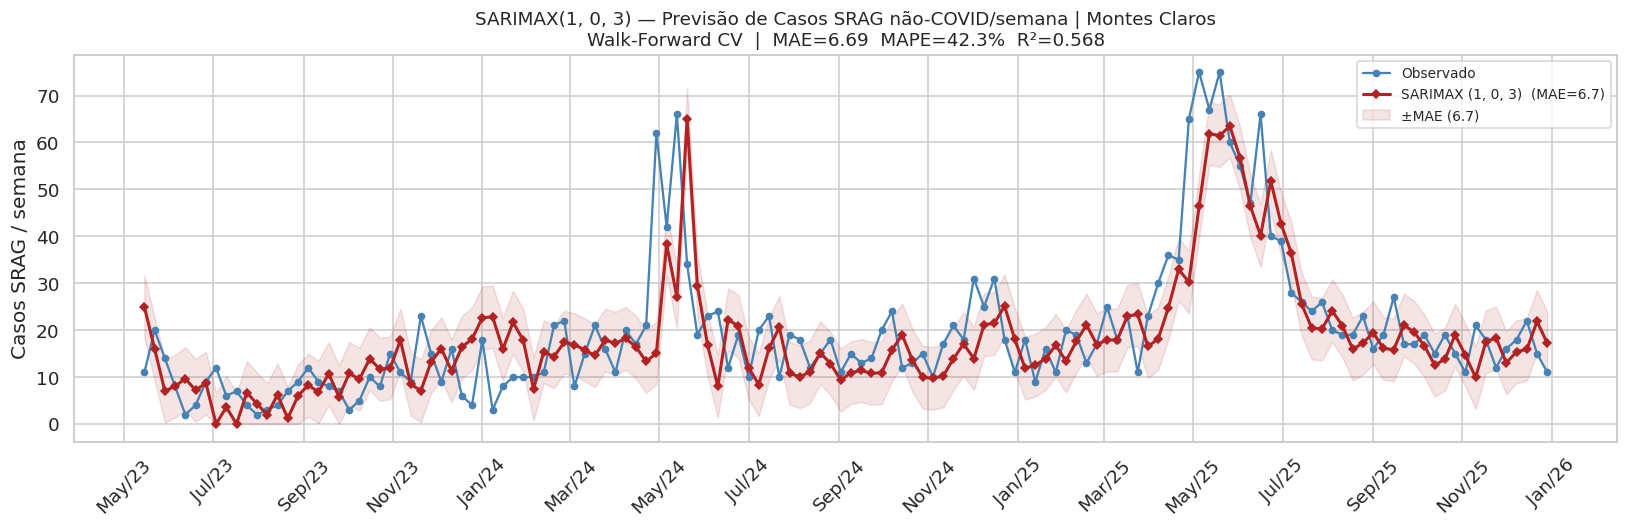

In [12]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(pred_dates, actuals, 'o-', color='steelblue', lw=1.5, ms=4, label='Observado')
ax.plot(pred_dates, preds,   'D-', color='firebrick', lw=2,   ms=4,
        label=f'SARIMAX {order}  (MAE={mae:.1f})')
ax.fill_between(
    pred_dates,
    np.clip(preds - mae, 0, None),
    preds + mae,
    alpha=0.12, color='firebrick', label=f'±MAE ({mae:.1f})'
)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.set_title(
    f'SARIMAX{order} — Previsão de Casos SRAG não-COVID/semana | Montes Claros\n'
    f'Walk-Forward CV  |  MAE={mae:.2f}  MAPE={mape:.1f}%  R²={r2:.3f}',
    fontsize=12
)
ax.set_ylabel('Casos SRAG / semana')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'resultado_sarimax_serie.png', dpi=150, bbox_inches='tight')
plt.show()

### 7b. Previsto × Observado (scatter) + Distribuição dos erros

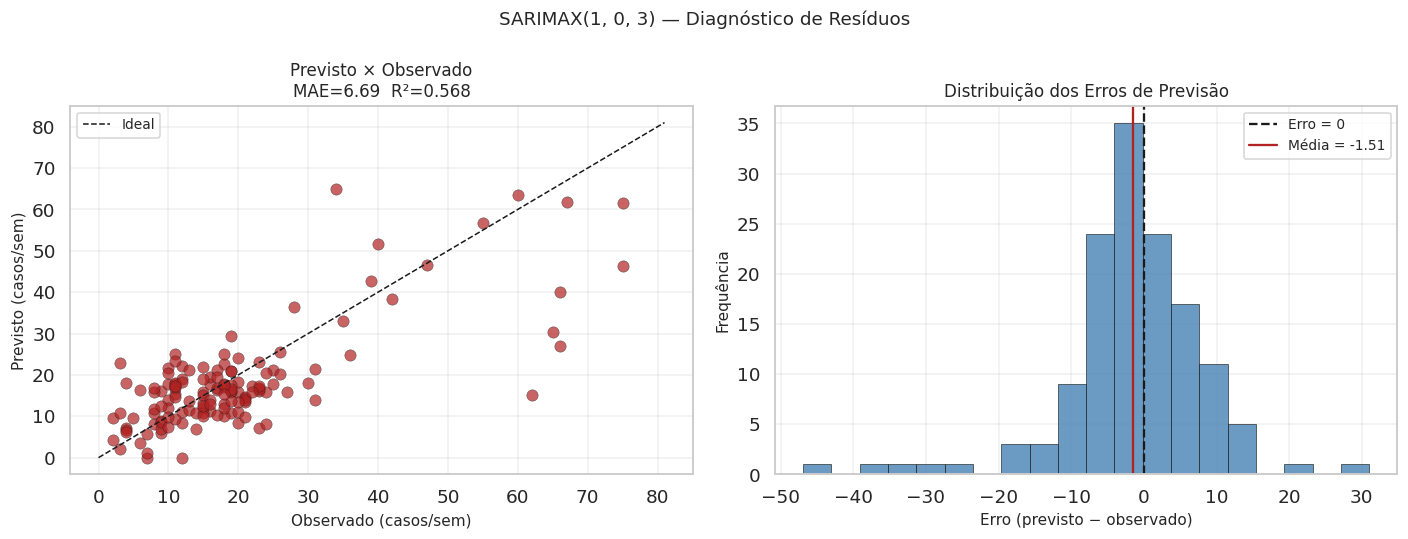


═══════════════════════════════════════════════════════
  RESUMO FINAL — SARIMAX para Casos SRAG/semana
═══════════════════════════════════════════════════════
  Modelo          : SARIMAX(1, 0, 3)
  Variáveis exóg. : ['temp_min_lag3', 'umid_min_lag2', 'orvalho_med_lag2', 'amp_term_lag2', 'precip_lag3', 'sin_sem', 'cos_sem']
  Semanas avaliadas: 138
  MAE             : 6.69 casos/semana
  MAPE            : 42.3%
  R²              : 0.568
  Erro médio      : -1.51 (bias)
  Desvio resíduos : 9.75
═══════════════════════════════════════════════════════

Figuras salvas em: /home/gabriel/dev/hackaton/srag_predicao/outputs


In [13]:
errors = preds - actuals

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
ax = axes[0]
ax.scatter(actuals, preds, color='firebrick', alpha=0.7, edgecolors='k', lw=0.3, s=55)
lim = max(actuals.max(), preds.max()) * 1.08
ax.plot([0, lim], [0, lim], 'k--', lw=1, label='Ideal')
ax.set_xlabel('Observado (casos/sem)', fontsize=10)
ax.set_ylabel('Previsto (casos/sem)', fontsize=10)
ax.set_title(f'Previsto × Observado\nMAE={mae:.2f}  R²={r2:.3f}', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Histograma de erros
ax = axes[1]
ax.hist(errors, bins=20, color='steelblue', edgecolor='k', lw=0.5, alpha=0.8)
ax.axvline(0, color='k', lw=1.5, ls='--', label='Erro = 0')
ax.axvline(errors.mean(), color='firebrick', lw=1.5, ls='-',
           label=f'Média = {errors.mean():.2f}')
ax.set_xlabel('Erro (previsto − observado)', fontsize=10)
ax.set_ylabel('Frequência', fontsize=10)
ax.set_title('Distribuição dos Erros de Previsão', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle(f'SARIMAX{order} — Diagnóstico de Resíduos', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'resultado_sarimax_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Resumo final ──────────────────────────────────────────────────────────
print("\n" + "═"*55)
print("  RESUMO FINAL — SARIMAX para Casos SRAG/semana")
print("═"*55)
print(f"  Modelo          : SARIMAX{order}")
print(f"  Variáveis exóg. : {EXOG_SARIMAX}")
print(f"  Semanas avaliadas: {len(preds)}")
print(f"  MAE             : {mae:.2f} casos/semana")
print(f"  MAPE            : {mape:.1f}%")
print(f"  R²              : {r2:.3f}")
print(f"  Erro médio      : {errors.mean():.2f} (bias)")
print(f"  Desvio resíduos : {errors.std():.2f}")
print("═"*55)
print("\nFiguras salvas em:", OUTPUTS_DIR)

## 8. Análise Retrospectiva — Pico SRAG 2025

> **Argumento pitch:** Se um sistema de predição baseado em dados climáticos estivesse em produção, o aumento de casos de maio–julho/2025 poderia ter sido antecipado com semanas de antecedência, permitindo que gestores ativassem protocolos preventivos antes da lotação hospitalar.

### 8a. O problema — casos observados no pico de 2025


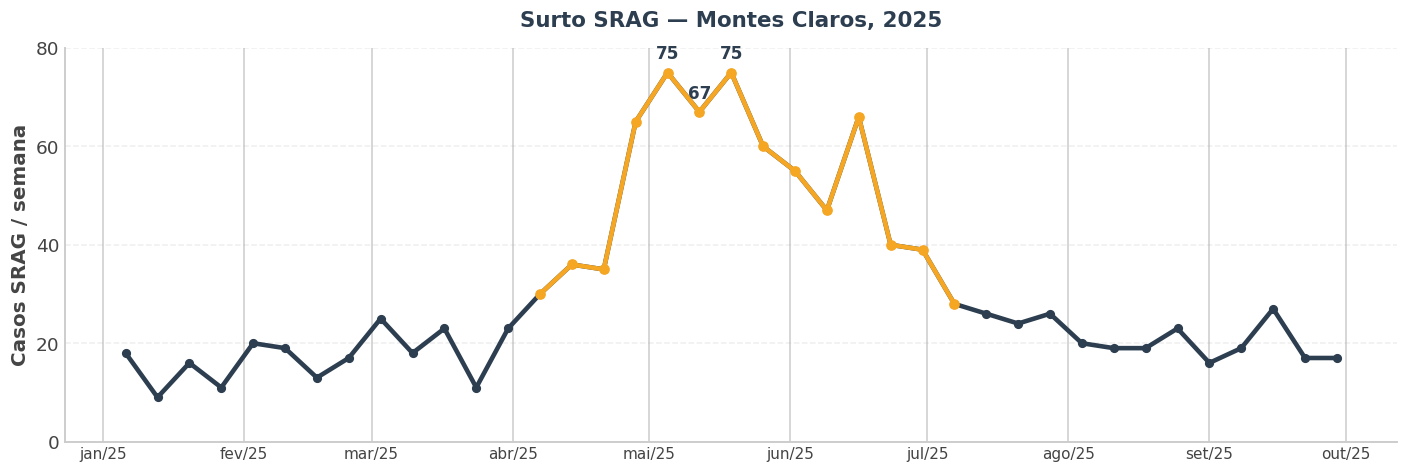

Figura salva: pitch_1_pico_observado.png


In [27]:
# ── Paleta dos slides ─────────────────────────────────────────────────────
COR_NAVY   = '#2C3E50'
COR_ORANGE = '#F5A623'

# ── Recorte temporal ─────────────────────────────────────────────────────
dates_arr = pd.to_datetime(pred_dates)
mask_pico = (dates_arr >= '2025-01-01') & (dates_arr <= '2025-09-30')
mask_peak = (dates_arr >= '2025-04-07') & (dates_arr <= '2025-07-7')

d_pico = dates_arr[mask_pico]
y_pico = actuals[mask_pico]
d_peak = dates_arr[mask_peak]
y_peak = actuals[mask_peak]

d_inicio_start = d_peak[0]
d_inicio_end   = d_peak[1]
d_fim_start    = d_peak[-2]
d_fim_end      = d_peak[-1]

fig, ax = plt.subplots(figsize=(13, 4.5), facecolor='white')
ax.set_facecolor('white')

ax.plot(d_pico, y_pico, '-o', color=COR_NAVY, lw=3, ms=5, zorder=3)
ax.plot(d_peak, y_peak, '-o', color=COR_ORANGE, lw=3, ms=6, zorder=4)

top_idx = np.argsort(y_pico)[-3:]
for i in top_idx:
    ax.annotate(
        f'{int(y_pico[i])}',
        xy=(d_pico[i], y_pico[i]),
        xytext=(0, 9),
        textcoords='offset points',
        ha='center', fontsize=11, fontweight='bold', color=COR_NAVY
    )

_meses_pt = ['jan','fev','mar','abr','mai','jun','jul','ago','set','out','nov','dez']
def _fmt_pt(x, _):
    d = mdates.num2date(x)
    return f"{_meses_pt[d.month-1]}/{str(d.year)[2:]}"

ax.xaxis.set_major_formatter(plt.FuncFormatter(_fmt_pt))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=0, fontsize=10, color='#444', ha='center')
ax.set_ylabel('Casos SRAG / semana', fontsize=13, color='#444', weight='bold')
ax.set_ylim(0, None)
ax.set_yticks(np.arange(0, int(y_pico.max()) + 21, 20))
ax.set_title('Surto SRAG — Montes Claros, 2025', fontsize=14, fontweight='bold', color=COR_NAVY, pad=14)
ax.tick_params(colors='#444', length=0)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['left'].set_color('#ccc')
ax.spines['bottom'].set_color('#ccc')
ax.grid(axis='y', alpha=0.2, color='#aaa', linestyle='--')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'pitch_1_pico_observado.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva: pitch_1_pico_observado.png")


### 8b. O diferencial — o modelo previu o pico semanas antes


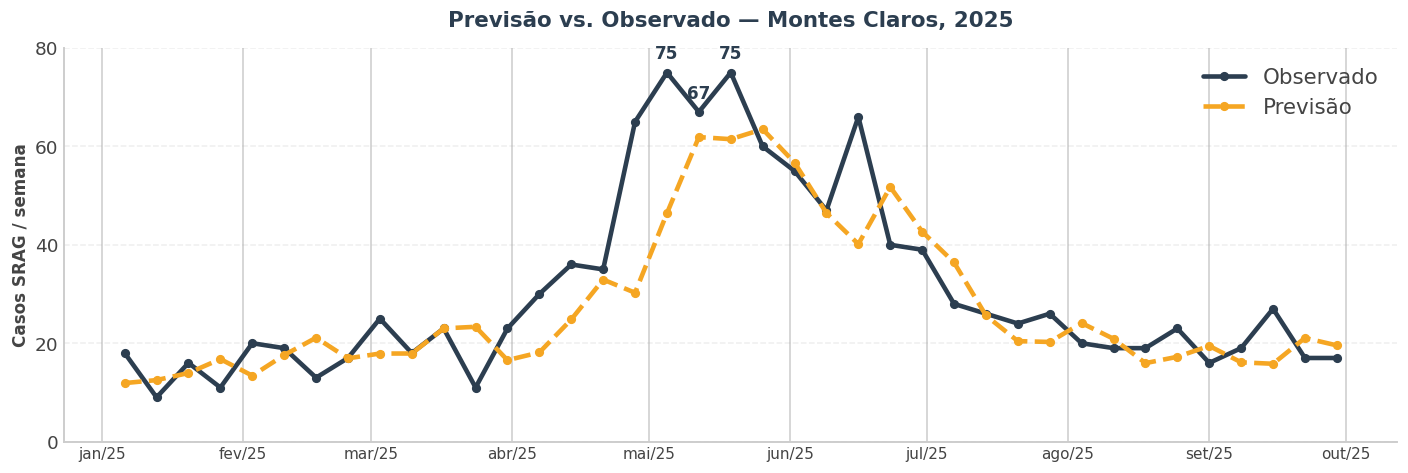

Figura salva: pitch_2_pred_vs_obs_pico.png


In [32]:
p_pico = preds[mask_pico]

fig, ax = plt.subplots(figsize=(13, 4.5), facecolor='white')
ax.set_facecolor('white')

ax.plot(d_pico, y_pico, '-o',  color=COR_NAVY,   lw=3, ms=5, label='Observado')
ax.plot(d_pico, p_pico, '--o', color=COR_ORANGE,  lw=3, ms=5, label='Previsão')

top_idx2 = np.argsort(y_pico)[-3:]
for i in top_idx2:
    ax.annotate(
        f'{int(y_pico[i])}',
        xy=(d_pico[i], y_pico[i]),
        xytext=(0, 9),
        textcoords='offset points',
        ha='center', fontsize=11, fontweight='bold', color=COR_NAVY
    )

_meses_pt = ['jan','fev','mar','abr','mai','jun','jul','ago','set','out','nov','dez']
def _fmt_pt(x, _):
    d = mdates.num2date(x)
    return f"{_meses_pt[d.month-1]}/{str(d.year)[2:]}"

ax.xaxis.set_major_formatter(plt.FuncFormatter(_fmt_pt))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=0, fontsize=10, color='#444', ha='center')
ax.set_ylabel('Casos SRAG / semana', fontsize=11, color='#444', weight='bold')
ax.set_ylim(0, None)
ax.set_yticks(np.arange(0, int(y_pico.max()) + 21, 20))
ax.set_title('Previsão vs. Observado — Montes Claros, 2025', fontsize=14, fontweight='bold', color=COR_NAVY, pad=14)
ax.tick_params(colors='#444', length=0)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['left'].set_color('#ccc')
ax.spines['bottom'].set_color('#ccc')
ax.grid(axis='y', alpha=0.2, color='#aaa', linestyle='--')
legend = ax.legend(fontsize=14, framealpha=0.0, labelcolor='#444')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'pitch_2_pred_vs_obs_pico.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva: pitch_2_pred_vs_obs_pico.png")
